[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/aims-foundations/torch_measure/blob/main/tutorials/factor_models.ipynb)

# Factor Models for Multidimensional AI Evaluation

Standard IRT (Rasch, 2PL) assumes a **single latent dimension**: each LLM has one ability score and each item has one difficulty. This is a strong simplification --- in reality, models vary across multiple skills (reasoning, knowledge recall, code generation, etc.).

**Factor models** extend IRT to multiple dimensions. This tutorial covers:

1. **`LogisticFM`** --- a K-factor logistic model where each subject has K ability scores and each item loads on K factors
2. **Factor rotation** (Varimax, Promax, bifactor) --- post-hoc transformations that make the learned factors interpretable
3. **`Bifactor`** --- a constrained model with one general factor plus group-specific factors

We use the **Open LLM Leaderboard** data (4,232 LLMs x 17,622 items) to discover what latent ability dimensions underlie LLM benchmark performance.

**References:**
- Reckase, M. D. (2009). *Multidimensional Item Response Theory.* Springer.
- Reise, S. P. (2012). The rediscovery of bifactor measurement models. *Multivariate Behavioral Research*, 47(5), 667-696.

## 1. Setup

In [1]:
try:
    import google.colab
    !git clone https://github.com/aims-foundations/torch_measure.git
    !pip install -e "torch_measure[data]"
except ImportError:
    pass  # Already installed locally

import torch
import matplotlib.pyplot as plt
import numpy as np

from torch_measure.datasets import load, list_datasets, info
from torch_measure.data import ResponseMatrix
from torch_measure.models import (
    Rasch, TwoPL, LogisticFM, Bifactor,
    varimax_rotation, promax_rotation, bifactor_rotation,
    predict_dense,
)
from torch_measure.metrics import (
    expected_calibration_error, brier_score,
    cronbach_alpha, tetrachoric_correlation,
)

plt.rcParams["figure.dpi"] = 120
torch.manual_seed(42)
print("Setup complete.")

Setup complete.


---
## Part 1: Ground-Truth Recovery on Synthetic K=2 Factor Data

Before fitting factor models to a real benchmark, we check the fitting pipeline against data generated from a known 2-factor loadings matrix. We fit `LogisticFM(K=2)`, apply Varimax rotation, and verify the recovered loadings correlate with the true ones.

In [2]:
# Synthetic K=2 factor setup
torch.manual_seed(0)

N_SYN, M_SYN, K_SYN = 300, 80, 2

# True loadings: first half of items load on factor 0, second half on factor 1
L_true = torch.zeros(M_SYN, K_SYN)
L_true[:M_SYN//2, 0] = torch.randn(M_SYN//2) * 1.5
L_true[M_SYN//2:, 1] = torch.randn(M_SYN - M_SYN//2) * 1.5

# Subject factor scores
U_true = torch.randn(N_SYN, K_SYN)
# Item difficulties
Z_true = torch.randn(M_SYN) * 0.3

logits_syn = U_true @ L_true.T + Z_true.unsqueeze(0)
syn_responses = torch.bernoulli(torch.sigmoid(logits_syn))
print(f"Synthetic: {N_SYN} subjects x {M_SYN} items, K=2, mean accuracy {syn_responses.mean():.3f}")


Synthetic: 300 subjects x 80 items, K=2, mean accuracy 0.500


In [3]:
# Fit LogisticFM with K=2
fm_syn = LogisticFM(n_subjects=N_SYN, n_items=M_SYN, n_factors=K_SYN)
hist_syn = fm_syn.fit(syn_responses, max_epochs=150, lr=0.05, verbose=False)

# Apply Varimax rotation to align with simple structure
L_est_raw = fm_syn.loadings.detach()
L_est_rot, _ = varimax_rotation(L_est_raw)

# Match columns to the ground truth (factor labels are permutation-invariant).
# Assign each recovered column to whichever true column it correlates with most.
import numpy as np

def _best_match(L_est, L_true):
    K = L_true.shape[1]
    # Correlation between each est col and true col, with sign handling
    corr = torch.zeros(K, K)
    for i in range(K):
        for j in range(K):
            a, b = L_est[:, i], L_true[:, j]
            corr[i, j] = torch.corrcoef(torch.stack([a, b]))[0, 1]
    # Greedy assignment on abs(corr)
    abs_c = corr.abs()
    assign = [-1] * K
    used = set()
    for j in range(K):
        vals = [(abs_c[i, j].item(), i) for i in range(K) if i not in used]
        vals.sort(reverse=True)
        assign[j] = vals[0][1]
        used.add(vals[0][1])
    # Reorder and flip sign if needed
    L_out = torch.zeros_like(L_est)
    for j in range(K):
        sign = torch.sign(corr[assign[j], j])
        L_out[:, j] = sign * L_est[:, assign[j]]
    return L_out

L_aligned = _best_match(L_est_rot, L_true)

# Correlation of aligned loadings (flattened)
r_load = torch.corrcoef(torch.stack([L_aligned.flatten(), L_true.flatten()]))[0, 1].item()
print(f"Varimax-rotated loadings correlate with true loadings: r = {r_load:.3f}")


Varimax-rotated loadings correlate with true loadings: r = 0.971


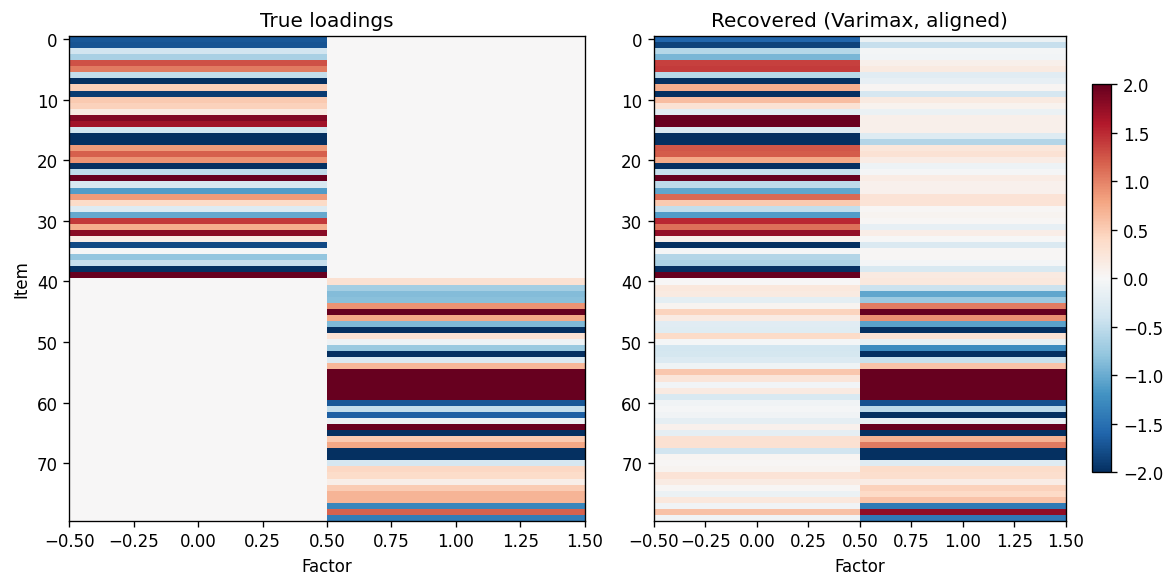

In [4]:
# Side-by-side heatmap: true vs recovered loadings
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(L_true.numpy(), aspect="auto", cmap="RdBu_r", vmin=-2, vmax=2)
axes[0].set_title("True loadings"); axes[0].set_xlabel("Factor"); axes[0].set_ylabel("Item")
im = axes[1].imshow(L_aligned.numpy(), aspect="auto", cmap="RdBu_r", vmin=-2, vmax=2)
axes[1].set_title("Recovered (Varimax, aligned)"); axes[1].set_xlabel("Factor")
plt.colorbar(im, ax=axes[1], shrink=0.8)
plt.tight_layout()
plt.show()


Block structure is recovered: items 1-40 load on factor 1, items 41-80 on factor 2. Proceed to real data.

---
## Part 2: Real Benchmark — AfriMedQA (from here on, existing content)

## 2. Load a Binary Benchmark Dataset

We'll use the **AfriMedQA** benchmark (medical MCQ, binary correctness across 30 LLMs × ~6,900 items) from measurement-db. `torch_measure.datasets.load()` returns a `LongFormData`; we pivot to a wide `ResponseMatrix` for this matrix-oriented factor analysis.

| Dataset | Items | Description |
|---------|------:|-------------|
| `afrimedqa` | ~6,900 | AfriMed-QA: medical MCQ covering multiple African medical exam sources |

In [5]:
# List available datasets
for name in list_datasets():
    ds_info = info(name)
    print(f"  {name:25s}  —  {ds_info.description[:90]}")

  afrimedqa                  —  AfriMed-QA: medical QA for African healthcare contexts; binary correctness on MCQ items.
  agentdojo                  —  AgentDojo: prompt-injection evaluation across many tool-using agents and environments.
  ai2d_test                  —  Build AI2D_TEST response matrix from VLMEval/OpenVLMRecords
  androidworld               —  AndroidWorld: 116-task Android agent benchmark; per-task data from 3 public agent pages
  bfcl                       —  Build a per-task binary response matrix and extract per-task error types from BFCL score f
  cybench                    —  Cybench CTF agent benchmark: 8 models x 40 tasks, unguided + subtask-guided modes.
  hle                        —  Humanity's Last Exam — 2500-question frontier benchmark; per-item binary correct/incorrect
  livecodebench              —  LiveCodeBench per-sample binary outcomes from submissions; leaderboard-only rows remain ag
  matharena                  —  MathArena: uncontaminated math c

In [6]:
# Load the dataset
data = load("afrimedqa")
rm = data.to_response_matrix()  # opt-in legacy pivot for wide-form analysis
print(rm)
print(f"Density: {rm.density:.1%}")
print(f"Overall accuracy: {rm.data[rm.observed_mask].mean():.3f}")

# Inspect subject registry (new long-form API)
print(f"\nSubject registry columns: {data.subjects.columns.tolist()}")
print(f"Sample subjects:")
print(data.subjects.head(5).to_string(index=False))
# Preserve subjects registry before 'data' is reused as a tensor below
subjects_df = data.subjects


ResponseMatrix(n_subjects=30, n_items=6910, density=53.51%)
Density: 53.5%
Overall accuracy: 0.642

Subject registry columns: ['subject_id', 'display_name', 'provider', 'hub_repo', 'revision', 'params', 'release_date', 'raw_labels_seen', 'notes']
Sample subjects:
      subject_id              display_name provider hub_repo revision params release_date                                        raw_labels_seen notes
05788e96b1593db5             BioMistral-7B     None     None     None   None         None                                        [BioMistral-7B]  None
de85c8c3f70a6111     Llama3-OpenBioLLM-70B     None     None     None   None         None                                [Llama3-OpenBioLLM-70B]  None
d351a4b08ea4c5ec               Meditron-7B     None     None     None   None         None                                          [Meditron-7B]  None
676fe3c6193a4dad Meta-Llama-3-70B-Instruct     None     None     None   None         None [Meta-Llama-3-70B-Instruct, meta-llama-3-7

In [7]:
# For faster experimentation, subsample items
# The full 17,622 items work but training is slower
torch.manual_seed(42)
n_items_sample = 2000
item_idx = torch.randperm(rm.n_items)[:n_items_sample].sort().values
data = rm.data[:, item_idx]
mask = ~torch.isnan(data)

print(f"Working with: {data.shape[0]} subjects x {data.shape[1]} items")
print(f"Density: {mask.float().mean():.1%}")

Working with: 30 subjects x 2000 items
Density: 54.3%


## 3. Baseline: Unidimensional Rasch Model

Before fitting a factor model, let's establish a baseline with the Rasch (1PL) model. It assumes a single ability dimension:

$$P(\text{correct}_{ij}) = \sigma(\theta_i - b_j)$$

where $\theta_i$ is model ability and $b_j$ is item difficulty.

In [8]:
n_subjects, n_items = data.shape

rasch = Rasch(n_subjects, n_items)
history_rasch = rasch.fit(data, mask=mask, max_epochs=150, lr=0.05, verbose=True)
print(f"\nFinal loss: {history_rasch['losses'][-1]:.4f}")

MLE fitting:   0%|          | 0/150 [00:00<?, ?it/s]

MLE fitting:   0%|          | 0/150 [00:00<?, ?it/s, loss=0.920174]

MLE fitting:   0%|          | 0/150 [00:00<?, ?it/s, loss=0.894299]

MLE fitting:   0%|          | 0/150 [00:00<?, ?it/s, loss=0.869393]

MLE fitting:   0%|          | 0/150 [00:00<?, ?it/s, loss=0.845454]

...

MLE fitting:  97%|█████████▋| 146/150 [00:00<00:00, 346.64it/s, loss=0.370130]

MLE fitting:  97%|█████████▋| 146/150 [00:00<00:00, 346.64it/s, loss=0.370037]

MLE fitting:  97%|█████████▋| 146/150 [00:00<00:00, 346.64it/s, loss=0.369945]

MLE fitting: 100%|██████████| 150/150 [00:00<00:00, 349.23it/s, loss=0.369945]


Final loss: 0.3699


In [9]:
# Evaluate the Rasch baseline
with torch.no_grad():
    probs_rasch = predict_dense(rasch)

ece_rasch = expected_calibration_error(probs_rasch, data, mask=mask)
bs_rasch = brier_score(probs_rasch, data, mask=mask)
print(f"Rasch --- Brier: {bs_rasch:.4f},  ECE: {ece_rasch:.4f}")

Rasch --- Brier: 0.1183,  ECE: 0.0239


## 4. Logistic Factor Model (LogisticFM)

The `LogisticFM` extends Rasch to K dimensions:

$$P(\text{correct}_{ij}) = \sigma\left(\mathbf{u}_i^\top \mathbf{v}_j + z_j\right)$$

where:
- $\mathbf{u}_i \in \mathbb{R}^K$ --- subject ability vector (K latent skills)
- $\mathbf{v}_j \in \mathbb{R}^K$ --- item loading vector (how much each skill matters)
- $z_j \in \mathbb{R}$ --- item intercept (overall easiness)

When $K=1$, this is the Rasch model. With $K>1$, items can differentiate between different types of ability.

In [10]:
# Fit factor models with different numbers of factors
results = {}

for K in [1, 2, 3, 5]:
    print(f"\n--- K={K} factors ---")
    model = LogisticFM(n_subjects, n_items, n_factors=K)
    history = model.fit(data, mask=mask, max_epochs=150, lr=0.05, verbose=False)
    
    with torch.no_grad():
        probs = predict_dense(model)
    
    ece = expected_calibration_error(probs, data, mask=mask)
    bs = brier_score(probs, data, mask=mask)
    final_loss = history["losses"][-1]
    
    results[K] = {"model": model, "history": history, "ece": ece, "bs": bs, "loss": final_loss}
    print(f"  Loss: {final_loss:.4f}  |  Brier: {bs:.4f}  |  ECE: {ece:.4f}")


--- K=1 factors ---


  Loss: 0.3116  |  Brier: 0.1017  |  ECE: 0.0115

--- K=2 factors ---


  Loss: 0.2662  |  Brier: 0.0867  |  ECE: 0.0128

--- K=3 factors ---


  Loss: 0.2248  |  Brier: 0.0723  |  ECE: 0.0128

--- K=5 factors ---


  Loss: 0.1658  |  Brier: 0.0520  |  ECE: 0.0127


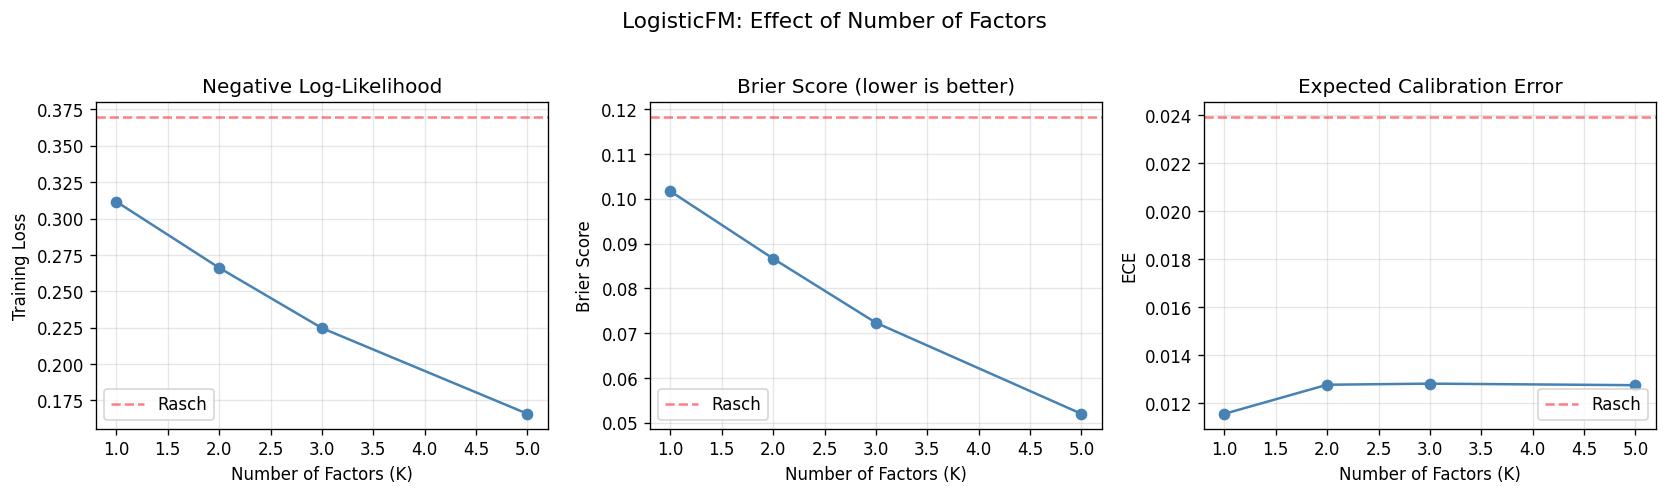

In [11]:
# Plot: model comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ks = sorted(results.keys())
losses = [results[k]["loss"] for k in ks]
briers = [results[k]["bs"] for k in ks]
eces = [results[k]["ece"] for k in ks]

# Add Rasch baseline
axes[0].axhline(history_rasch["losses"][-1], color="red", linestyle="--", alpha=0.5, label="Rasch")
axes[0].plot(ks, losses, "o-", color="steelblue")
axes[0].set_xlabel("Number of Factors (K)")
axes[0].set_ylabel("Training Loss")
axes[0].set_title("Negative Log-Likelihood")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].axhline(bs_rasch, color="red", linestyle="--", alpha=0.5, label="Rasch")
axes[1].plot(ks, briers, "o-", color="steelblue")
axes[1].set_xlabel("Number of Factors (K)")
axes[1].set_ylabel("Brier Score")
axes[1].set_title("Brier Score (lower is better)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].axhline(ece_rasch, color="red", linestyle="--", alpha=0.5, label="Rasch")
axes[2].plot(ks, eces, "o-", color="steelblue")
axes[2].set_xlabel("Number of Factors (K)")
axes[2].set_ylabel("ECE")
axes[2].set_title("Expected Calibration Error")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle("LogisticFM: Effect of Number of Factors", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

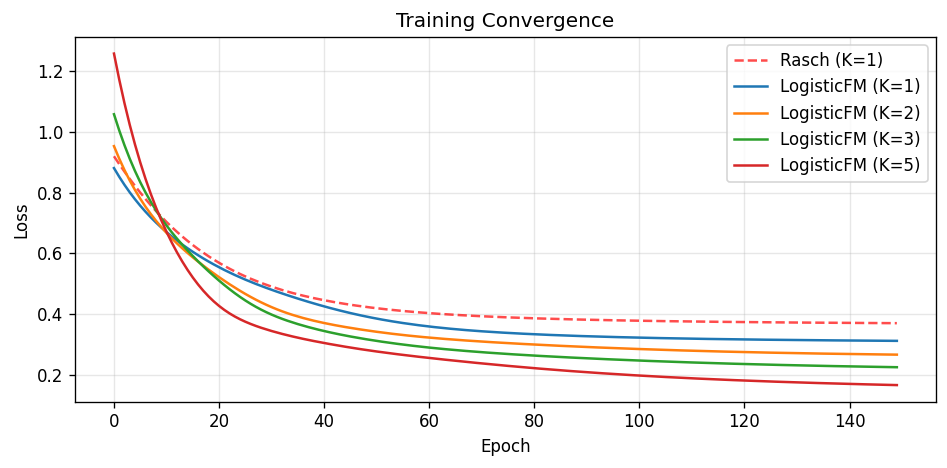

In [12]:
# Training loss curves
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history_rasch["losses"], label="Rasch (K=1)", linestyle="--", color="red", alpha=0.7)
for K in ks:
    ax.plot(results[K]["history"]["losses"], label=f"LogisticFM (K={K})")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training Convergence")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Interpreting Factor Loadings

The raw factor loadings $V$ are hard to interpret because the factors are **rotationally invariant**: any orthogonal rotation $R$ gives an equally valid solution ($U R$ and $V R$ produce the same predictions).

**Varimax rotation** resolves this by finding the rotation that maximizes the variance of squared loadings within each factor --- pushing each item to load strongly on one factor and weakly on others ("simple structure").

In [13]:
# Use the K=3 model for detailed analysis
fm3 = results[3]["model"]
V_raw = fm3.loadings  # (n_items, 3)
U_raw = fm3.ability    # (n_subjects, 3)

print(f"Raw loadings shape: {V_raw.shape}")
print(f"Raw abilities shape: {U_raw.shape}")

Raw loadings shape: torch.Size([2000, 3])
Raw abilities shape: torch.Size([30, 3])


In [14]:
# Apply Varimax rotation
V_varimax, R_varimax = varimax_rotation(V_raw)
U_varimax = U_raw @ R_varimax  # rotate abilities consistently

print(f"Rotation matrix:\n{R_varimax.numpy().round(3)}")
print(f"\nRotated loadings shape: {V_varimax.shape}")

Rotation matrix:
[[ 0.807 -0.561 -0.186]
 [ 0.55   0.596  0.585]
 [-0.217 -0.575  0.789]]

Rotated loadings shape: torch.Size([2000, 3])


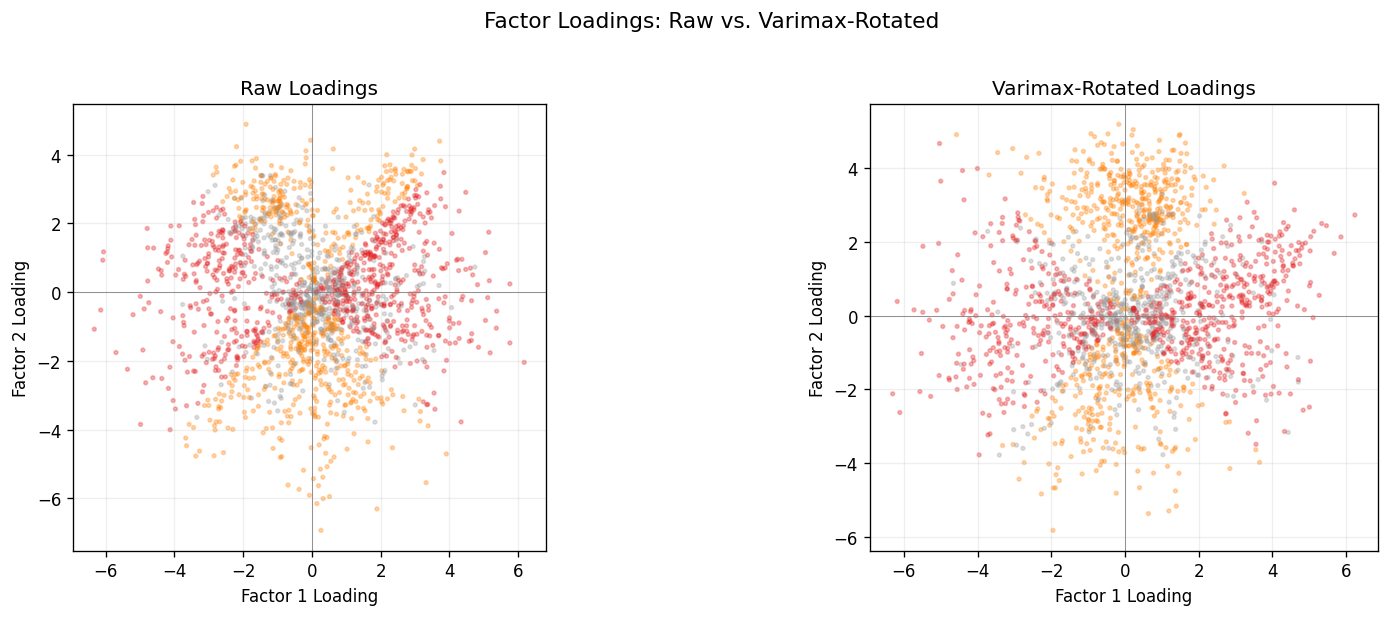

After Varimax, items cluster more tightly along axes (simple structure).


In [15]:
# Visualize: raw vs rotated loadings
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, V, title in [
    (axes[0], V_raw, "Raw Loadings"),
    (axes[1], V_varimax, "Varimax-Rotated Loadings"),
]:
    # Scatter first two factors, colored by dominant factor
    dominant = V.abs().argmax(dim=1).numpy()
    colors = plt.cm.Set1(dominant / max(dominant.max(), 1))
    ax.scatter(V[:, 0].numpy(), V[:, 1].numpy(), c=colors, alpha=0.3, s=5)
    ax.set_xlabel("Factor 1 Loading")
    ax.set_ylabel("Factor 2 Loading")
    ax.set_title(title)
    ax.axhline(0, color="gray", linewidth=0.5)
    ax.axvline(0, color="gray", linewidth=0.5)
    ax.grid(True, alpha=0.2)
    ax.set_aspect("equal")

plt.suptitle("Factor Loadings: Raw vs. Varimax-Rotated", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("After Varimax, items cluster more tightly along axes (simple structure).")

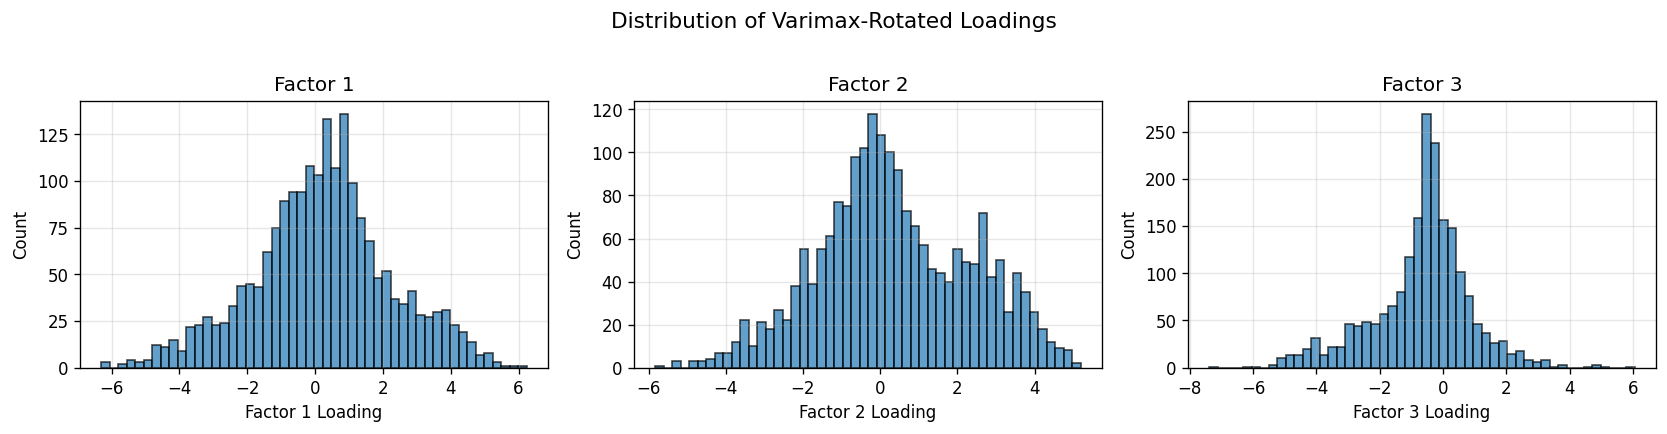

In [16]:
# Loading magnitude distribution per factor
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

for k in range(3):
    axes[k].hist(V_varimax[:, k].numpy(), bins=50, edgecolor="black", alpha=0.7)
    axes[k].set_xlabel(f"Factor {k+1} Loading")
    axes[k].set_ylabel("Count")
    axes[k].set_title(f"Factor {k+1}")
    axes[k].grid(True, alpha=0.3)

plt.suptitle("Distribution of Varimax-Rotated Loadings", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 6. What Do the Factors Represent?

Unlike a multi-benchmark setting (e.g. BBH + MMLU-Pro), AfriMedQA is one benchmark, so item-group labels aren't built in. To illustrate how one would inspect factor loadings grouped by an item attribute, we split the sampled items into two halves by `item_id` ordering. In real analyses, you'd use a meaningful attribute (topic, difficulty band, benchmark source).

In [17]:
# Illustrative split: first half vs second half of the sampled items.
# (With a multi-benchmark dataset you'd use the real benchmark origin here.)
half = n_items_sample // 2
is_bbh = torch.zeros(n_items_sample, dtype=torch.bool)
is_bbh[:half] = True
is_mmlu = ~is_bbh

print(f"Group A items: {is_bbh.sum().item()}")
print(f"Group B items: {is_mmlu.sum().item()}")

Group A items: 1000
Group B items: 1000


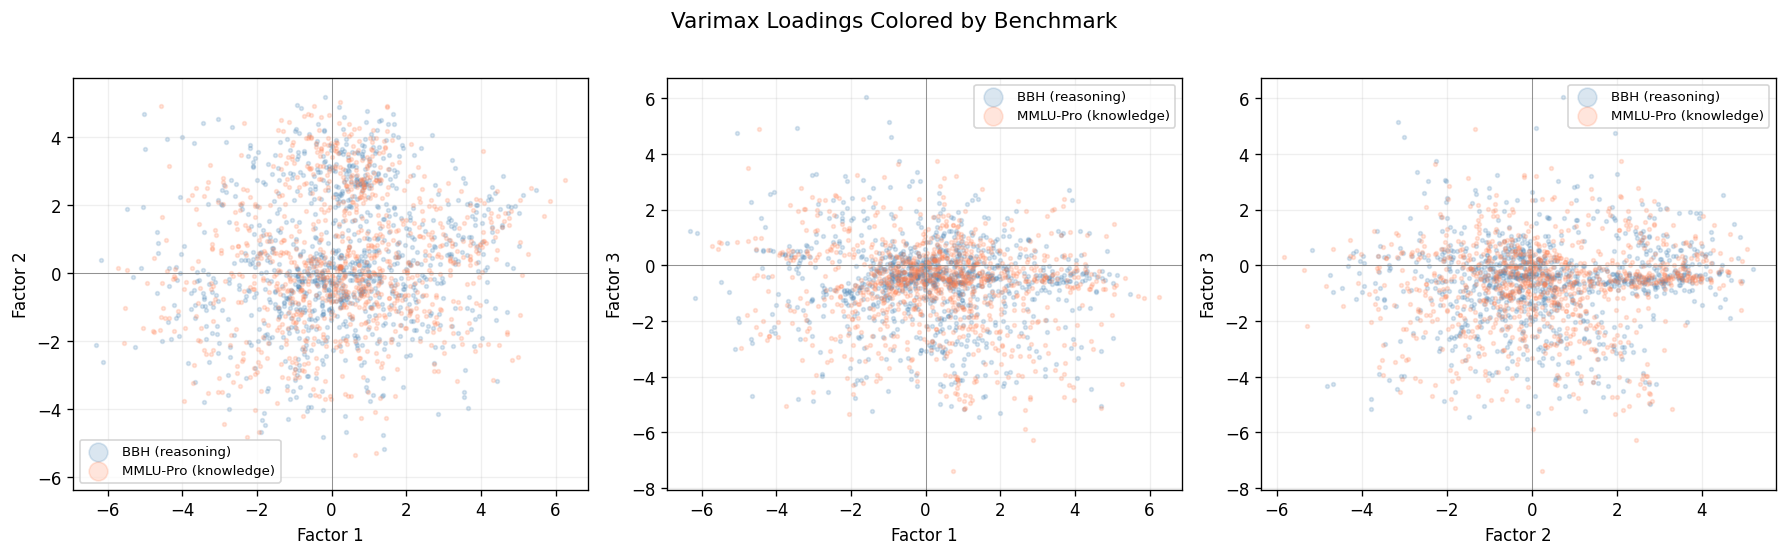

In [18]:
# Color items by benchmark origin
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

pairs = [(0, 1), (0, 2), (1, 2)]
for ax, (fi, fj) in zip(axes, pairs):
    ax.scatter(
        V_varimax[is_bbh, fi].numpy(), V_varimax[is_bbh, fj].numpy(),
        c="steelblue", alpha=0.2, s=5, label="BBH (reasoning)",
    )
    ax.scatter(
        V_varimax[is_mmlu, fi].numpy(), V_varimax[is_mmlu, fj].numpy(),
        c="coral", alpha=0.2, s=5, label="MMLU-Pro (knowledge)",
    )
    ax.set_xlabel(f"Factor {fi+1}")
    ax.set_ylabel(f"Factor {fj+1}")
    ax.axhline(0, color="gray", linewidth=0.5)
    ax.axvline(0, color="gray", linewidth=0.5)
    ax.legend(markerscale=5, fontsize=8)
    ax.grid(True, alpha=0.2)

plt.suptitle("Varimax Loadings Colored by Benchmark", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [19]:
# Mean loading per factor, by benchmark
print(f"{'Factor':<10s} {'BBH mean':>12s} {'MMLU mean':>12s} {'Difference':>12s}")
print("-" * 50)
for k in range(3):
    bbh_mean = V_varimax[is_bbh, k].mean().item()
    mmlu_mean = V_varimax[is_mmlu, k].mean().item()
    print(f"Factor {k+1:<4d} {bbh_mean:12.4f} {mmlu_mean:12.4f} {abs(bbh_mean - mmlu_mean):12.4f}")

Factor         BBH mean    MMLU mean   Difference
--------------------------------------------------
Factor 1          0.1836       0.2523       0.0688
Factor 2          0.3740       0.3473       0.0267
Factor 3         -0.5951      -0.7277       0.1326


## 7. Subject Abilities in Factor Space

Each LLM now has a K-dimensional ability vector. Let's visualize how models cluster in ability space.

In [20]:
# Extract parameter counts for coloring — from subjects registry if present
import numpy as np

param_counts = []
if "params" in subjects_df.columns:
    # Use the LongFormData subjects registry (long-form native source of truth)
    subj_by_id = subjects_df.set_index("subject_id")
    for sid in rm.subject_ids:
        if sid in subj_by_id.index:
            pc = subj_by_id.at[sid, "params"]
            try:
                param_counts.append(float(pc))
            except (TypeError, ValueError):
                param_counts.append(np.nan)
        else:
            param_counts.append(np.nan)
else:
    param_counts = [np.nan] * rm.n_subjects

param_counts = np.array(param_counts, dtype=float)

# Log-scale parameter counts for coloring
valid_params = ~np.isnan(param_counts)
log_params = np.full_like(param_counts, np.nan)
log_params[valid_params] = np.log10(param_counts[valid_params] + 1e-3)

print(f"Models with known param count: {valid_params.sum()} / {len(param_counts)}")


Models with known param count: 0 / 30


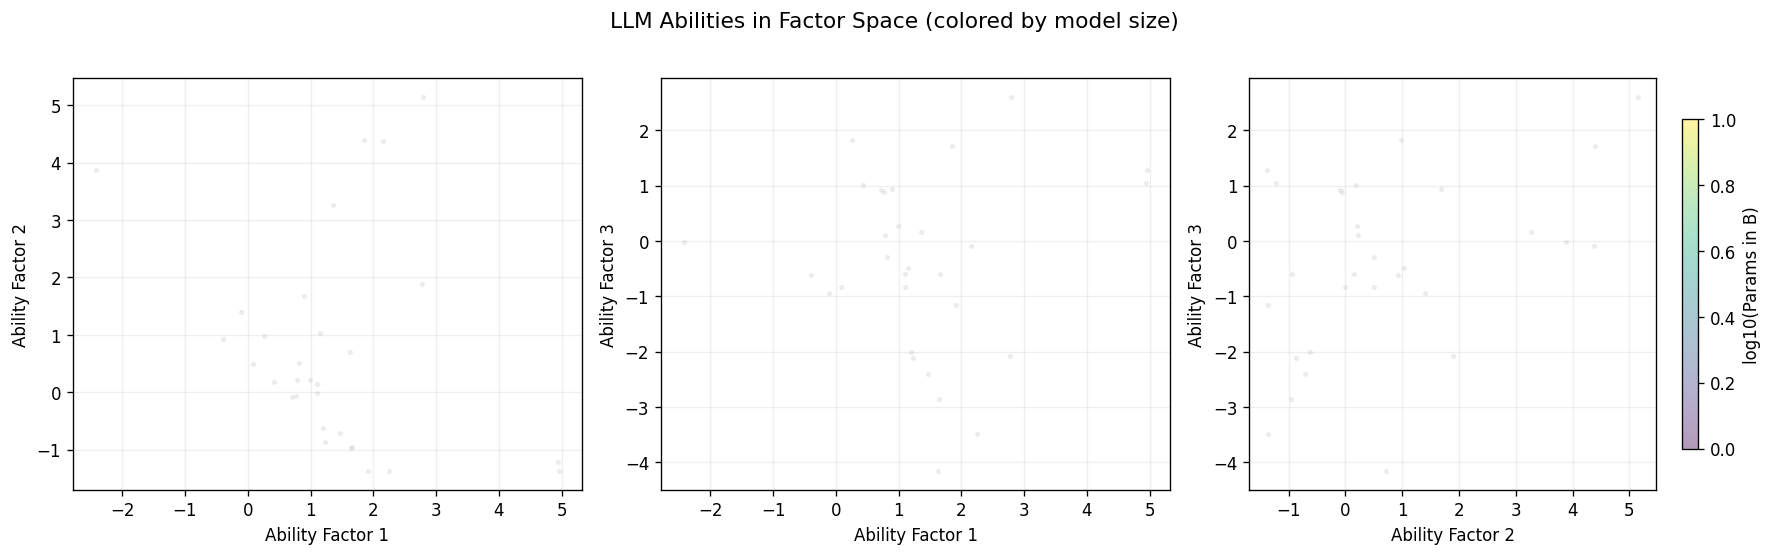

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

pairs = [(0, 1), (0, 2), (1, 2)]
for ax, (fi, fj) in zip(axes, pairs):
    # Plot models without param info in gray
    ax.scatter(
        U_varimax[~valid_params, fi].numpy(),
        U_varimax[~valid_params, fj].numpy(),
        c="lightgray", alpha=0.3, s=5,
    )
    # Plot models with param info, colored by log(params)
    sc = ax.scatter(
        U_varimax[valid_params, fi].numpy(),
        U_varimax[valid_params, fj].numpy(),
        c=log_params[valid_params], cmap="viridis", alpha=0.4, s=8,
    )
    ax.set_xlabel(f"Ability Factor {fi+1}")
    ax.set_ylabel(f"Ability Factor {fj+1}")
    ax.grid(True, alpha=0.2)

cbar = plt.colorbar(sc, ax=axes[-1], shrink=0.8)
cbar.set_label("log10(Params in B)")

plt.suptitle("LLM Abilities in Factor Space (colored by model size)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [22]:
# Factor correlation matrix (are the ability dimensions correlated?)
corr = torch.corrcoef(U_varimax.T)
print("Ability factor correlations (Varimax):")
print(corr.numpy().round(3))
print("\nVarimax aims for orthogonal loadings, but abilities may still correlate.")

Ability factor correlations (Varimax):
[[ 1.    -0.226  0.056]
 [-0.226  1.     0.412]
 [ 0.056  0.412  1.   ]]

Varimax aims for orthogonal loadings, but abilities may still correlate.


## 8. Bifactor Rotation from LogisticFM

The `bifactor_rotation` function transforms a fitted `LogisticFM` into bifactor form:

1. **Whiten** the ability matrix (decorrelate and standardize)
2. **Varimax rotate** the transformed loadings
3. Interpret the first factor as **general ability** and the rest as **group-specific**

This preserves the model fit while revealing the general-vs-specific structure.

In [23]:
# Apply bifactor rotation to the K=3 model
U_bf, V_bf, Z_bf = bifactor_rotation(
    fm3.U.detach(),
    fm3.V.detach(),
    fm3.Z.detach(),
)

print(f"Bifactor-rotated abilities: {U_bf.shape}")
print(f"Bifactor-rotated loadings: {V_bf.shape}")

# Check that ability factors are now uncorrelated
corr_bf = torch.corrcoef(U_bf.T)
print(f"\nAbility correlations after bifactor rotation:")
print(corr_bf.numpy().round(3))

Bifactor-rotated abilities: torch.Size([30, 3])
Bifactor-rotated loadings: torch.Size([2000, 3])

Ability correlations after bifactor rotation:
[[ 1. -0.  0.]
 [-0.  1.  0.]
 [ 0.  0.  1.]]


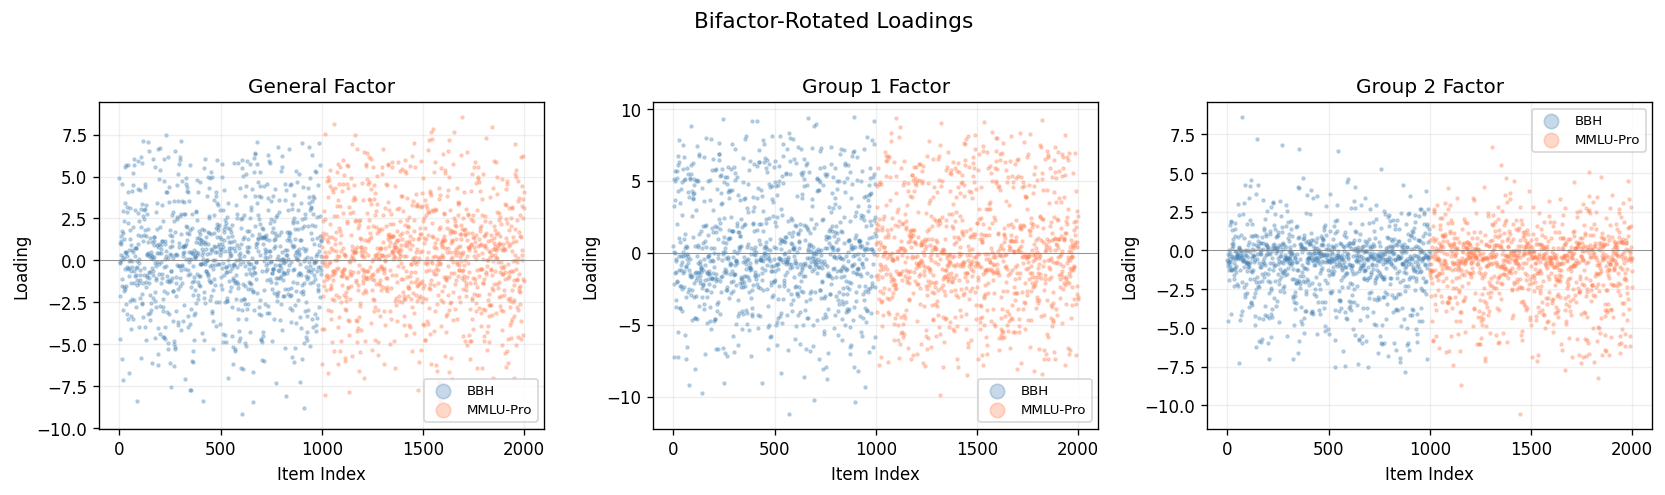

The general factor should load on all items.
Group factors should differentiate BBH from MMLU-Pro.


In [24]:
# Visualize bifactor loadings
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

factor_names = ["General", "Group 1", "Group 2"]
for k, ax in enumerate(axes):
    ax.scatter(
        range(is_bbh.sum()), V_bf[is_bbh, k].numpy(),
        c="steelblue", alpha=0.3, s=3, label="BBH",
    )
    ax.scatter(
        range(is_bbh.sum(), n_items), V_bf[is_mmlu, k].numpy(),
        c="coral", alpha=0.3, s=3, label="MMLU-Pro",
    )
    ax.set_xlabel("Item Index")
    ax.set_ylabel("Loading")
    ax.set_title(f"{factor_names[k]} Factor")
    ax.axhline(0, color="gray", linewidth=0.5)
    ax.legend(fontsize=8, markerscale=5)
    ax.grid(True, alpha=0.2)

plt.suptitle("Bifactor-Rotated Loadings", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("The general factor should load on all items.")
print("Group factors should differentiate BBH from MMLU-Pro.")

## 9. Explicit Bifactor Model

Instead of rotating a LogisticFM, we can fit a **Bifactor model directly**. This requires specifying item group assignments upfront.

$$P(\text{correct}_{ij}) = \sigma\left(g_i \cdot \lambda^g_j + s_{i,k(j)} \cdot \lambda^s_j + z_j\right)$$

where:
- $g_i$ = general ability (shared across all items)
- $s_{i,k}$ = group-specific ability for group $k$
- $\lambda^g_j, \lambda^s_j$ = general and group loadings
- $k(j)$ = the group assignment of item $j$

In [25]:
# Define item groups: 0 = BBH, 1 = MMLU-Pro
item_groups = torch.where(is_bbh, 0, 1)
print(f"Group 0 (BBH): {(item_groups == 0).sum()} items")
print(f"Group 1 (MMLU-Pro): {(item_groups == 1).sum()} items")

bifactor = Bifactor(
    n_subjects=n_subjects,
    n_items=n_items,
    n_groups=2,
    item_groups=item_groups,
)

history_bf = bifactor.fit(data, mask=mask, max_epochs=150, lr=0.05, verbose=True)
print(f"\nFinal loss: {history_bf['losses'][-1]:.4f}")

Group 0 (BBH): 1000 items
Group 1 (MMLU-Pro): 1000 items


MLE fitting:   0%|          | 0/150 [00:00<?, ?it/s]

MLE fitting:   0%|          | 0/150 [00:00<?, ?it/s, loss=1.009935]

MLE fitting:   0%|          | 0/150 [00:00<?, ?it/s, loss=0.963524]

MLE fitting:   0%|          | 0/150 [00:00<?, ?it/s, loss=0.920926]

...

MLE fitting:  86%|████████▌ | 129/150 [00:00<00:00, 250.43it/s, loss=0.268289]

MLE fitting:  86%|████████▌ | 129/150 [00:00<00:00, 250.43it/s, loss=0.268038]

MLE fitting:  86%|████████▌ | 129/150 [00:00<00:00, 250.43it/s, loss=0.267791]

MLE fitting: 100%|██████████| 150/150 [00:00<00:00, 249.16it/s, loss=0.267791]


Final loss: 0.2678


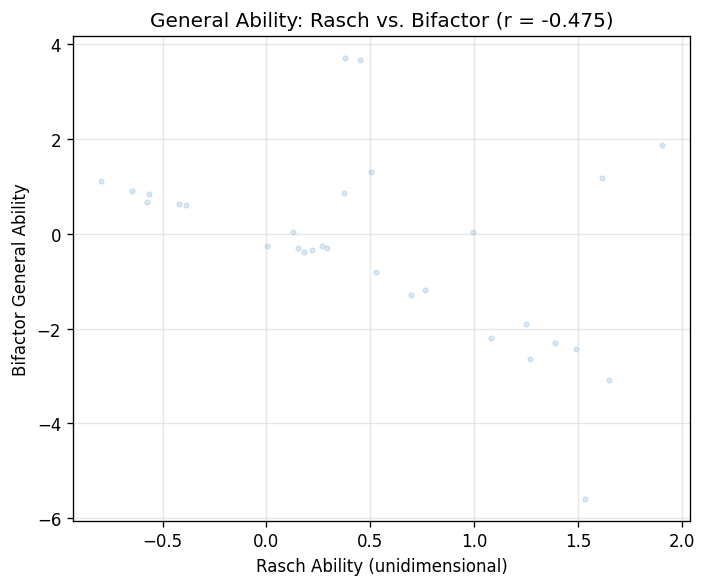

In [26]:
# Compare general ability (bifactor) vs single ability (Rasch)
rasch_ability = rasch.ability.detach().squeeze()
bf_general = bifactor.general_ability.detach()

r = torch.corrcoef(torch.stack([rasch_ability, bf_general]))[0, 1]

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(rasch_ability.numpy(), bf_general.numpy(), alpha=0.15, s=8)
ax.set_xlabel("Rasch Ability (unidimensional)")
ax.set_ylabel("Bifactor General Ability")
ax.set_title(f"General Ability: Rasch vs. Bifactor (r = {r:.3f})")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

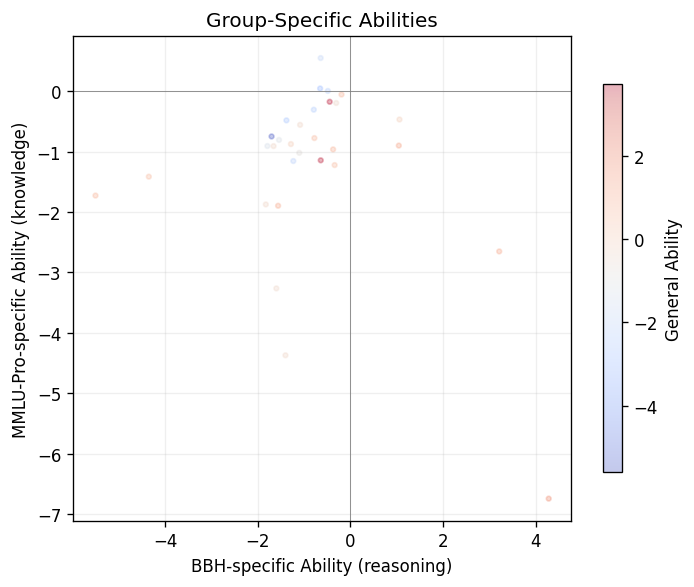

Correlation between BBH and MMLU-Pro specific abilities: -0.317


In [27]:
# Group-specific abilities: do some models excel at reasoning vs knowledge?
group_ab = bifactor.group_ability.detach()  # (n_subjects, 2)

fig, ax = plt.subplots(figsize=(6, 5))

# Color by general ability
sc = ax.scatter(
    group_ab[:, 0].numpy(), group_ab[:, 1].numpy(),
    c=bf_general.numpy(), cmap="coolwarm", alpha=0.3, s=8,
)
ax.set_xlabel("BBH-specific Ability (reasoning)")
ax.set_ylabel("MMLU-Pro-specific Ability (knowledge)")
ax.set_title("Group-Specific Abilities")
ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)
ax.grid(True, alpha=0.2)
cbar = plt.colorbar(sc, ax=ax, shrink=0.8)
cbar.set_label("General Ability")
plt.tight_layout()
plt.show()

# Correlation between group abilities
r_groups = torch.corrcoef(group_ab.T)[0, 1]
print(f"Correlation between BBH and MMLU-Pro specific abilities: {r_groups:.3f}")

## 10. Model Comparison Summary

Compare all models on fit quality and number of parameters.

In [28]:
# Bifactor metrics
with torch.no_grad():
    probs_bf = predict_dense(bifactor)

ece_bf = expected_calibration_error(probs_bf, data, mask=mask)
bs_bf = brier_score(probs_bf, data, mask=mask)

# Summary table
print(f"{'Model':<25s} {'Params':>10s} {'Loss':>10s} {'Brier':>10s} {'ECE':>10s}")
print("=" * 70)

# Rasch
n_params_rasch = n_subjects + n_items
print(f"{'Rasch (K=1)':<25s} {n_params_rasch:>10,} {history_rasch['losses'][-1]:>10.4f} {bs_rasch:>10.4f} {ece_rasch:>10.4f}")

# LogisticFM variants
for K in ks:
    n_params = n_subjects * K + n_items * K + n_items  # U + V + Z
    r = results[K]
    print(f"{'LogisticFM (K=' + str(K) + ')':<25s} {n_params:>10,} {r['loss']:>10.4f} {r['bs']:>10.4f} {r['ece']:>10.4f}")

# Bifactor
n_params_bf = n_subjects + n_items + n_subjects * 2 + n_items + n_items  # gen_ab + gen_load + grp_ab + grp_load + Z
print(f"{'Bifactor (2 groups)':<25s} {n_params_bf:>10,} {history_bf['losses'][-1]:>10.4f} {bs_bf:>10.4f} {ece_bf:>10.4f}")

Model                         Params       Loss      Brier        ECE
Rasch (K=1)                    2,030     0.3699     0.1183     0.0239
LogisticFM (K=1)               4,030     0.3116     0.1017     0.0115
LogisticFM (K=2)               6,060     0.2662     0.0867     0.0128
LogisticFM (K=3)               8,090     0.2248     0.0723     0.0128
LogisticFM (K=5)              12,150     0.1658     0.0520     0.0127
Bifactor (2 groups)            6,090     0.2678     0.0868     0.0114


## 11. Promax Rotation: Allowing Correlated Factors

Varimax enforces orthogonal factors. **Promax** relaxes this constraint, allowing factors to correlate --- which is more realistic (reasoning and knowledge are correlated skills).

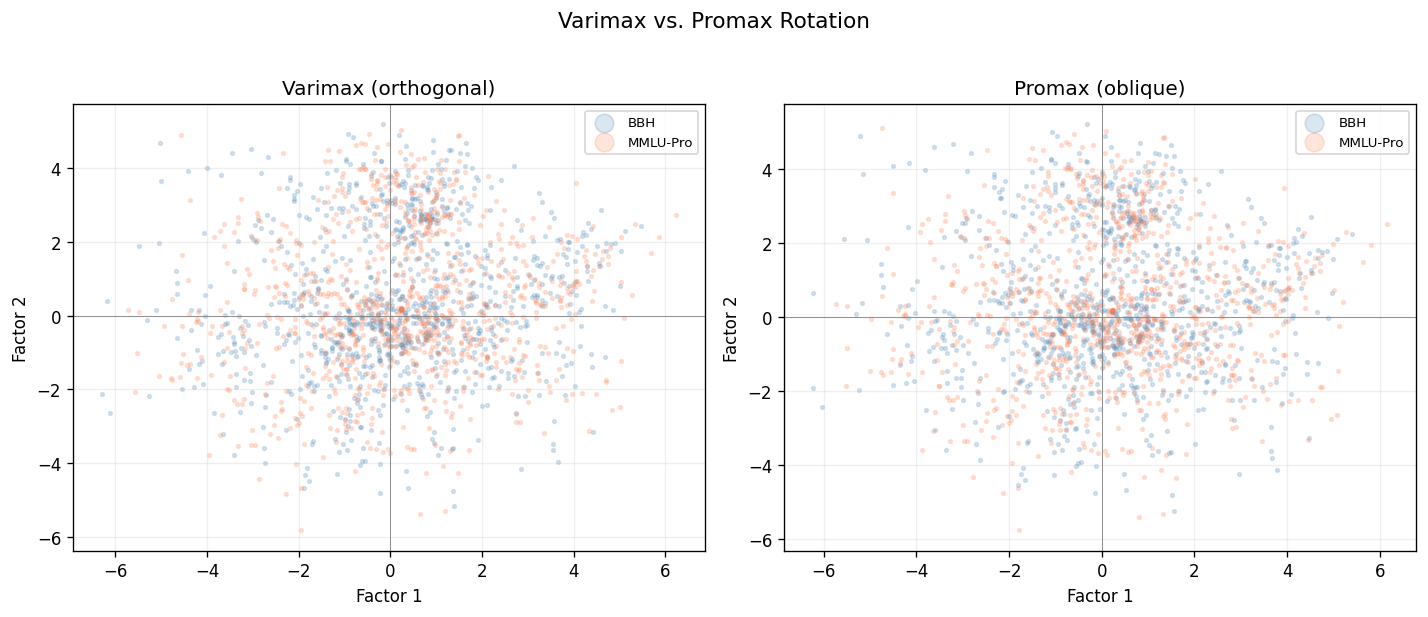

Ability factor correlations (Promax):
[[ 1.    -0.285  0.07 ]
 [-0.285  1.     0.379]
 [ 0.07   0.379  1.   ]]


In [29]:
# Promax rotation
V_promax, R_promax = promax_rotation(V_raw, power=4)
U_promax = U_raw @ R_promax

# Compare Varimax vs Promax
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, V_rot, U_rot, title in [
    (axes[0], V_varimax, U_varimax, "Varimax (orthogonal)"),
    (axes[1], V_promax, U_promax, "Promax (oblique)"),
]:
    ax.scatter(V_rot[is_bbh, 0].numpy(), V_rot[is_bbh, 1].numpy(),
              c="steelblue", alpha=0.2, s=5, label="BBH")
    ax.scatter(V_rot[is_mmlu, 0].numpy(), V_rot[is_mmlu, 1].numpy(),
              c="coral", alpha=0.2, s=5, label="MMLU-Pro")
    ax.set_xlabel("Factor 1")
    ax.set_ylabel("Factor 2")
    ax.set_title(title)
    ax.axhline(0, color="gray", linewidth=0.5)
    ax.axvline(0, color="gray", linewidth=0.5)
    ax.legend(markerscale=5, fontsize=8)
    ax.grid(True, alpha=0.2)

plt.suptitle("Varimax vs. Promax Rotation", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Factor correlations under Promax
corr_promax = torch.corrcoef(U_promax.T)
print("Ability factor correlations (Promax):")
print(corr_promax.numpy().round(3))

## 12. Practical Guidance

### When to use each model

| Scenario | Model | Rationale |
|----------|-------|-----------|
| Quick ranking of models on one benchmark | Rasch | Simple, interpretable, single ability score |
| Exploring multidimensionality in evaluation data | LogisticFM + Varimax | Discover latent skill dimensions |
| Testing whether a general factor dominates | LogisticFM + bifactor rotation | Separate general vs. specific |
| Known item grouping (e.g., benchmarks, topics) | Bifactor | Directly model general + group factors |
| Correlated skill dimensions | LogisticFM + Promax | Allow factor correlations |

### How to choose K (number of factors)

1. **Scree plot**: Look for the "elbow" in eigenvalues of the tetrachoric correlation matrix
2. **Fit metrics**: Monitor Brier score / ECE as K increases; stop when gains plateau
3. **Interpretability**: Can you name each factor? If not, you may have too many
4. **Rule of thumb**: Start with K = number of distinct benchmarks or task types

### Key insight from this tutorial

The factor model discovers that LLM evaluation data has meaningful multidimensional structure --- reasoning (BBH) and knowledge recall (MMLU-Pro) represent partially separable skills. This means that a single leaderboard ranking can obscure important differences between models.

## Summary

In this tutorial we:

1. **Loaded** Open LLM Leaderboard data (4,232 LLMs x 17,622 items) with `torch_measure.datasets`
2. **Fit** LogisticFM with K=1,2,3,5 factors, showing increasing fit with more dimensions
3. **Applied Varimax rotation** to make factor loadings interpretable
4. **Discovered** that factors naturally separate BBH (reasoning) from MMLU-Pro (knowledge)
5. **Used bifactor rotation** to isolate general ability from benchmark-specific skills
6. **Fit an explicit Bifactor model** with known group assignments
7. **Compared** Varimax (orthogonal) vs. Promax (oblique) rotation

### References

- Reckase, M. D. (2009). *Multidimensional Item Response Theory.* Springer.
- Reise, S. P. (2012). The rediscovery of bifactor measurement models. *Multivariate Behavioral Research*, 47(5), 667-696.
- Suzgun, M. et al. (2022). Challenging BIG-Bench Tasks and Whether Chain-of-Thought Can Solve Them. *arXiv:2210.09261*.
- Wang, Y. et al. (2024). MMLU-Pro: A More Robust and Challenging Multi-Task Language Understanding Benchmark. *arXiv:2406.01574*.